# Chunk Size Analysis for RAG Indexing

Analyzes the regulatory documents corpus to determine the optimal chunk size based on article-level segmentation.

In [1]:
import subprocess
import sys

def ensure_package(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

ensure_package("pypdf")
ensure_package("tiktoken")

In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tiktoken
from pypdf import PdfReader

## 1. Document Discovery

In [3]:
DOCS_DIR = Path("../docs")
SUPPORTED_EXTENSIONS = {".pdf", ".txt", ".md"}

doc_files = [
    p for p in DOCS_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
]

print(f"Found {len(doc_files)} documents")
for f in sorted(doc_files):
    print(f"  {f.relative_to(DOCS_DIR)}")

Found 16 documents
  CO/UIAF/circular/2021/001_reporte_operaciones_sospechosas.txt
  CO/UIAF/circular/2021/004_sanciones_financieras_proliferacion_jurisdicciones_riesgo.txt
  CO/UIAF/circular/2022/002_umbrales_reporte_beneficiario_final.txt
  CO/UIAF/circular/2022/005_transferencias_electronicas_banca_corresponsal_regla_viaje.txt
  CO/UIAF/circular/2023/003_activos_virtuales_reporte_electronico_peps_digitales.txt
  MX/CNBV/disposicion/2020/003_reporte_operaciones_efectivo_estructuradas.txt
  MX/CNBV/disposicion/2021/009_sanciones_financieras_internacionales_jurisdicciones_riesgo.txt
  MX/CNBV/disposicion/2022/012_identificacion_beneficiario_final.txt
  MX/CNBV/disposicion/2023/008_peps_transferencias_internacionales.txt
  MX/CNBV/disposicion/2024/015_pldft_instituciones_tecnologia_financiera_banca_digital.txt
  PE/SBS/circular/2020/001_procedimientos_reporte_operaciones_sospechosas.txt
  PE/SBS/circular/2022/002_identificacion_beneficiario_final_personas_juridicas.txt
  PE/SBS/resoluci

## 2. Text Extraction

In [4]:
def extract_text(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix == ".pdf":
        reader = PdfReader(str(path))
        return "\n".join(page.extract_text() or "" for page in reader.pages)
    else:
        return path.read_text(encoding="utf-8", errors="replace")


docs = {}
for p in doc_files:
    try:
        docs[p] = extract_text(p)
    except Exception as e:
        print(f"WARNING: could not read {p}: {e}")

print(f"Successfully read {len(docs)} documents")

Successfully read 16 documents


## 3. Article Segmentation

In [5]:
ARTICLE_RE = re.compile(
    r"^(Art[ií]culo\s+\d+|Art\.\s*\d+|ART[ÍI]CULO\s+\d+)",
    re.IGNORECASE | re.MULTILINE,
)


def split_into_articles(text: str) -> list[str]:
    lines = text.splitlines(keepends=True)
    segments: list[str] = []
    current: list[str] = []
    found_any = False

    for line in lines:
        if ARTICLE_RE.match(line.strip()):
            if current:
                segments.append("".join(current).strip())
            current = [line]
            found_any = True
        else:
            current.append(line)

    if current:
        segments.append("".join(current).strip())

    if not found_any:
        return [text.strip()]

    return [s for s in segments if s]


all_segments: list[str] = []
for path, text in docs.items():
    segs = split_into_articles(text)
    print(f"  {path.name}: {len(segs)} segment(s)")
    all_segments.extend(segs)

print(f"\nTotal segments: {len(all_segments)}")

  002_identificacion_beneficiario_final_personas_juridicas.txt: 13 segment(s)
  001_procedimientos_reporte_operaciones_sospechosas.txt: 14 segment(s)
  1560_registros_digitales_monitoreo_automatizado_pldft.txt: 16 segment(s)
  2660_gestion_riesgo_la_ft.txt: 22 segment(s)
  4838_modificacion_regimen_peps_procedimientos_reporte.txt: 9 segment(s)
  3200_transferencias_electronicas_corresponsalia_regla_viaje.txt: 13 segment(s)
  005_transferencias_electronicas_banca_corresponsal_regla_viaje.txt: 13 segment(s)
  002_umbrales_reporte_beneficiario_final.txt: 14 segment(s)
  003_activos_virtuales_reporte_electronico_peps_digitales.txt: 13 segment(s)
  004_sanciones_financieras_proliferacion_jurisdicciones_riesgo.txt: 12 segment(s)
  001_reporte_operaciones_sospechosas.txt: 16 segment(s)
  012_identificacion_beneficiario_final.txt: 18 segment(s)
  015_pldft_instituciones_tecnologia_financiera_banca_digital.txt: 14 segment(s)
  008_peps_transferencias_internacionales.txt: 17 segment(s)
  009_san

## 4. Token Counting

In [6]:
enc = tiktoken.get_encoding("cl100k_base")

token_counts = [len(enc.encode(seg)) for seg in all_segments]
token_counts = np.array(token_counts)

print(f"Encoded {len(token_counts)} segments")

Encoded 231 segments


## 5. Statistical Analysis

In [7]:
stats = {
    "count":  len(token_counts),
    "mean":   float(np.mean(token_counts)),
    "median": float(np.median(token_counts)),
    "std":    float(np.std(token_counts)),
    "min":    int(np.min(token_counts)),
    "max":    int(np.max(token_counts)),
    "p25":    float(np.percentile(token_counts, 25)),
    "p50":    float(np.percentile(token_counts, 50)),
    "p75":    float(np.percentile(token_counts, 75)),
    "p80":    float(np.percentile(token_counts, 80)),
    "p90":    float(np.percentile(token_counts, 90)),
    "p95":    float(np.percentile(token_counts, 95)),
}

print("Token length statistics (per article segment)")
print("-" * 40)
for k, v in stats.items():
    print(f"  {k:>8}: {v:.1f}")

Token length statistics (per article segment)
----------------------------------------
     count: 231.0
      mean: 125.2
    median: 116.0
       std: 41.9
       min: 52.0
       max: 306.0
       p25: 93.5
       p50: 116.0
       p75: 152.5
       p80: 163.0
       p90: 180.0
       p95: 201.5


## 6. Histogram

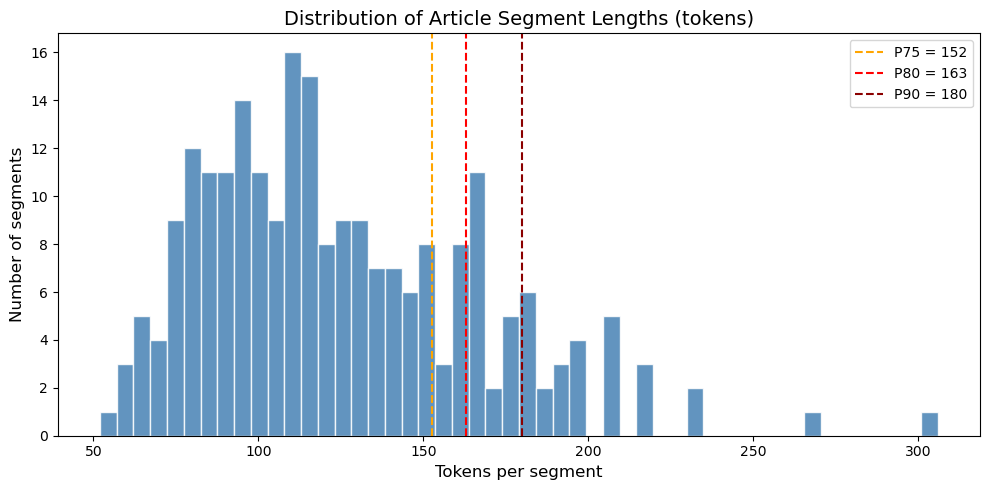

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(token_counts, bins=50, color="steelblue", edgecolor="white", alpha=0.85)

percentile_lines = {
    "P75": (stats["p75"], "orange"),
    "P80": (stats["p80"], "red"),
    "P90": (stats["p90"], "darkred"),
}
for label, (val, color) in percentile_lines.items():
    ax.axvline(val, color=color, linestyle="--", linewidth=1.5, label=f"{label} = {val:.0f}")

ax.set_xlabel("Tokens per segment", fontsize=12)
ax.set_ylabel("Number of segments", fontsize=12)
ax.set_title("Distribution of Article Segment Lengths (tokens)", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Recommendation

In [11]:
p80_raw = stats["p80"]
chunk_size = round(p80_raw / 50) * 50
overlap = round(chunk_size * 0.15 / 10) * 10

print(f"chunk_size = {chunk_size}")
print(f"overlap    = {overlap}")

chunk_size = 150
overlap    = 20


In [10]:
from IPython.display import Markdown, display

recommendation = f"""## Chunk Size Recommendation
- chunk_size: {chunk_size}
- overlap: {overlap}
- Rationale: P80 of article length is {p80_raw:.0f} tokens. 80% of articles fit in one chunk. Overlap is 15% of chunk size."""

display(Markdown(recommendation))
print(recommendation)

## Chunk Size Recommendation
- chunk_size: 150
- overlap: 20
- Rationale: P80 of article length is 163 tokens. 80% of articles fit in one chunk. Overlap is 15% of chunk size.

## Chunk Size Recommendation
- chunk_size: 150
- overlap: 20
- Rationale: P80 of article length is 163 tokens. 80% of articles fit in one chunk. Overlap is 15% of chunk size.
